# Planet Basemap Downloader

Use this notebook to explore and download Planet surface reflectance basemaps using the Orders API (SDK v3.0+).

**Prerequisites**: Planet API key and recent Planet SDK package (planet>=3.0.0.).

This notebook assumes the user will create an order using a geojson with a single feature. Please modify as needed for other inputs.

In [1]:
#!pip install planet contextily geopandas matplotlib pandas requests

  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
   ---------------------------------------- 0.0/3.5 MB ? eta -:--:--
   ---------------------------------------- 3.5/3.5 MB 16.8 MB/s  0:00:00
  Created wheel for pyqrcode: filename=pyqrcode-1.2.1-py3-none-any.whl size=36277 sha256=f8a77a0cc3e6cee666287ce4adb44623d48ba4372fd6f59523c11e6964a45d2f
  Stored in directory: c:\users\emilia\appdata\local\pip\cache\wheels\44\33\11\89edacddc8aa48c447282d6800826b398fe9277f6149cfd096
Successfully built pyqrcode

   ------ ---------------------------------  2/12 [tqdm]
   ------ ---------------------------------  2/12 [tqdm]
   ---------- -----------------------------  3/12 [pyjwt]
   ------------- -------------------------

In [2]:
import os
import sys
import json
from pathlib import Path
from datetime import datetime
from typing import Optional, List

import contextily as ctx
import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
import requests
from requests.auth import HTTPBasicAuth

# Planet SDK
try:
    import planet
    from planet import Planet

    planet_version = planet.__version__
    major_version = int(planet_version.split('.')[0])

    # Verify the version is current, >=3.0
    if major_version < 3:
        raise ImportError(f"Planet SDK {planet_version} detected. Requires >=3.0.0")

    print(f"Planet SDK {planet_version}")
except ImportError as e:
    print(f"Error: {e}")
    print("Install: pip install planet>=3.0.0")
    sys.exit(1)

Planet SDK 3.6.0


In [3]:
# Retrieve your API key from an environment variable or set it directly here
api_key = os.getenv('PL_API_KEY') or "API_KEY_HERE"
auth = HTTPBasicAuth(api_key, '')

# Test connection
try:
    Planet()
    print("API key validated")
except Exception as e:
    raise ValueError(f"API key validation failed: {e}")

API key validated


In [4]:
# Make a directory in which to save downloaded basemaps
OUT_DIR = Path("basemaps")
OUT_DIR.mkdir(parents=True, exist_ok=True)

### Load and validate our geometries

In [5]:
SUBSCRIPTION_AOI = os.path.join("SPARC_AOI_Juba.geojson")
os.path.exists(SUBSCRIPTION_AOI)

True

In [6]:
gdf = gpd.read_file(SUBSCRIPTION_AOI)
gdf

,fid,id,Area,geometry
0,1,1,345949236,"MULTIPOLYGON (((31.5537 4.78057, 31.54008 4.78..."


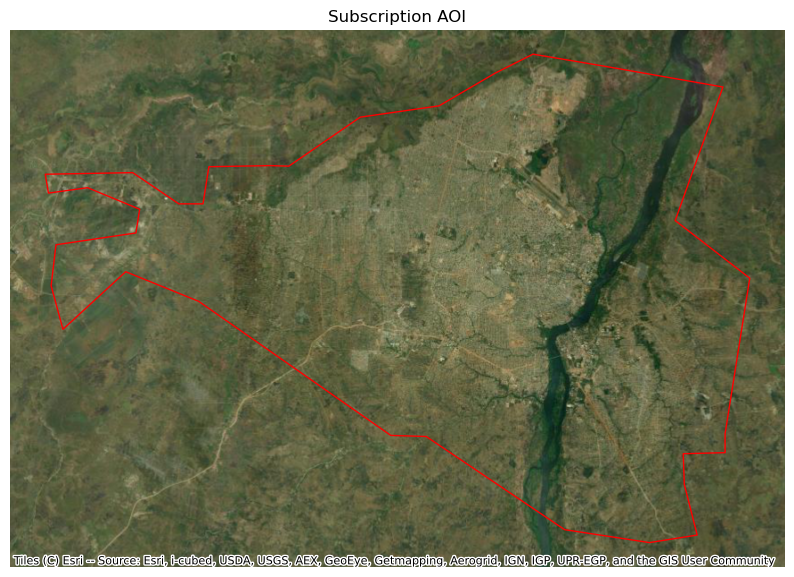

In [7]:
f, ax = plt.subplots(figsize=(10, 10))
gdf.plot(ax=ax, edgecolor='red', facecolor='none')
ctx.add_basemap(ax, crs=gdf.crs.to_string(), source=ctx.providers.Esri.WorldImagery)
ax.set_title("Subscription AOI")
ax.axis('off')
plt.show()

In [8]:
URL = "https://api.planet.com/features/v0/ogc/my/collections"
VALIDATE_URL = f"{URL}/validate"  # for validation only
session = requests.Session()
session.auth = (api_key, "")

with open(SUBSCRIPTION_AOI, "r") as f:
    geojson_data = json.load(f)

valid_features = []
invalid_features = []

if geojson_data.get("type") == "FeatureCollection":
    features = geojson_data.get("features", [])
else:
    # If it's a single Feature, wrap it
    features = [geojson_data]

for idx, feat in enumerate(features):
    geometry = feat.get("geometry")
    if geometry is None:
        continue

    res = session.post(VALIDATE_URL, json=geometry)
    if res.status_code != 200:
        print(f"Validation API error for feature {idx}: {res.status_code} {res.text}")
        invalid_features.append({"index": idx, "error": res.text})
        continue

    # Prepare a minimal Feature body for API calls
    feature_body = {
        "type": "Feature",
        "id": feat.get("id", str(idx)),
        "properties": feat.get("properties", {}),
        "geometry": geometry,
    }
    valid_features.append(feature_body)

print("Valid features:", len(valid_features))
if invalid_features:
    print("Invalid:", invalid_features)

Validation API error for feature 0: 401 {"detail":"Invalid username/password."}
Valid features: 0
Invalid: [{'index': 0, 'error': '{"detail":"Invalid username/password."}'}]


In [9]:
processed_aoi = valid_features[0]['geometry'] # saving the first valid geometry for a basemaps order
processed_aoi

IndexError: list index out of range

### Identify Basemap Needed

In [ ]:
def get_basemap_categories(auth, match_keyword=None):
    """
    Browse pages of Basemaps Series descriptions API to find all available
    basemap categories.
    """
    series_url = 'https://api.planet.com/basemaps/v1/series'
    basemapServiceResponse = requests.get(url=series_url, auth=auth)
    basemaps = basemapServiceResponse.raise_for_status()

    if basemapServiceResponse.status_code != 204:
        basemaps = json.loads(basemapServiceResponse.text)
        entry = [meta["name"] for meta in basemaps["series"]]
        while "_next" in basemaps["_links"]:
            # browse pages until finding the right basemaps name
            basemapServiceResponse = requests.get(
                url=basemaps["_links"]["_next"], auth=auth)
            basemaps = basemapServiceResponse.raise_for_status()
            if basemapServiceResponse.status_code != 204:
                basemaps = json.loads(basemapServiceResponse.text)
            entry += [meta["name"] for meta in basemaps["series"]]
        if match_keyword:
            entry = [name for name in entry
                     if match_keyword.lower() in name.lower()]
        return entry


def get_basemap_names(
    auth, category="PS sen2_normalized_analytic weekly subscription"):
    """
    Browse pages of Basemaps Series descriptions API to find all available
    basemap names by category.
    """
    series_url = 'https://api.planet.com/basemaps/v1/series'
    basemapServiceResponse = requests.get(url=series_url, auth=auth)

    basemaps = basemapServiceResponse.raise_for_status()
    if basemapServiceResponse.status_code != 204:
        basemaps = json.loads(basemapServiceResponse.text)

        entry = [meta for meta in basemaps["series"]
                 if category == meta["name"]]

        while not entry and "_next" in basemaps["_links"]:
            # browse pages until finding the right basemaps name
            basemapServiceResponse = requests.get(
                url=basemaps["_links"]["_next"], auth=auth)
            basemaps = basemapServiceResponse.raise_for_status()
            if basemapServiceResponse.status_code != 204:
                basemaps = json.loads(basemapServiceResponse.text)

            entry = [meta for meta in basemaps["series"]
                     if category == meta["name"]]

        url = entry[0]["_links"]["mosaics"]
        link_response = requests.get(url, auth=auth)
        sr_basemaps = json.loads(link_response.text)

        mosaic_names = [meta["name"] for meta in sr_basemaps["mosaics"]]

        return mosaic_names

In [ ]:
get_basemap_categories(auth, "analytic monthly subscription")

In [ ]:
get_basemap_names(auth, "PS sen2_normalized_analytic monthly subscription")[-10:]

### Order data

In [ ]:
mosaic_name = 'ps_monthly_sen2_normalized_analytic_subscription_2025_06_mosaic'

In [ ]:
def create_basemap_order(
    aoi_geojson: dict,
    mosaic_name: str,
    order_name: Optional[str] = None
) -> dict:
    """
    Create Planet basemap order.

    Args:
        aoi_geojson: GeoJSON geometry for AOI
        mosaic_name: Basemap mosaic identifier
        order_name: Optional custom order name

    Returns:
        dict: Order response with ID and status

    Raises:
        Exception: If order creation fails
    """
    if not order_name:
        order_name = f"basemap_order_{datetime.now().strftime('%Y%m%d_%H%M%S')}"

    order_payload = {
        "name": order_name,
        "source_type": "basemaps",
        "order_type": "partial",
        "products": [
            {
                "mosaic_name": mosaic_name,
                "geometry": aoi_geojson
            }
        ],
        "tools": [
            {"merge": {}},
            {"clip": {}}
        ]
    }

    try:
        client = Planet()
        order = client.orders.create_order(order_payload)

        print(f"✅ Order created: {order['id']}")
        print(f"Status: {order['state']}")
        return order
    except Exception as e:
        raise Exception(f"Order creation failed: {e}")

order = create_basemap_order(processed_aoi, mosaic_name)
order_id = order['id']

In [ ]:
def monitor_order(order_id: str, poll_interval: int = 10) -> dict:
    """
    Monitor order until completion.

    Args:
        order_id: Planet order ID
        poll_interval: Seconds between status checks

    Returns:
        dict: Completed order details
    """
    client = Planet()

    print(f"⏳ Monitoring order: {order_id}")
    print("Typical processing time: 5-15 minutes\n")

    try:
        final_order = client.orders.wait(order_id, delay=poll_interval)

        if final_order == 'success':
            print(f"✅ Order completed")
        else:
            print(f"⚠️  Order state: {final_order}")

        return final_order
    except Exception as e:
        raise Exception(f"Order monitoring failed: {e}")

completed_order = monitor_order(order_id)

In [ ]:
def download_order_assets(
    order_id: str,
    output_directory: Path,
    overwrite: bool = False
) -> List[Path]:
    """
    Download all assets from completed order.

    Args:
        order_id: Planet order ID
        output_directory: Download destination
        overwrite: Overwrite existing files if True

    Returns:
        List[Path]: Paths to downloaded files
    """
    client = Planet()

    print(f"📥 Downloading to: {output_directory}")

    try:
        client.orders.download_order(
            order_id,
            directory=str(output_directory),
            overwrite=overwrite,
            progress_bar=True
        )

        downloaded_files = [f for f in output_directory.glob("**/*") if f.is_file()]

        print(f"\n✅ Downloaded {len(downloaded_files)} file(s)")
        for f in downloaded_files:
            size_mb = f.stat().st_size / (1024 * 1024)
            print(f"  {f.name} ({size_mb:.2f} MB)")

        return downloaded_files
    except Exception as e:
        raise Exception(f"Download failed: {e}")

downloaded_files = download_order_assets(order_id, OUT_DIR)

In [ ]:
# Verify download
summary = pd.DataFrame([
    {"Item": "Order ID", "Value": order_id},
    {"Item": "Mosaic", "Value": mosaic_name},
    {"Item": "Files", "Value": len(downloaded_files)},
    {"Item": "Location", "Value": str(OUT_DIR.absolute())}
])

print(summary)

---

**Resources**:
- [Planet Basemaps Docs](https://docs.planet.com/data/imagery/basemaps/)
- [Planet SDK](https://github.com/planetlabs/planet-client-python)
- [Planet Support](https://support.planet.com/)